# 03 — Feature selection: single-vehicle time series (heavy_user)

This is the notebook that fixes the coach's real, confirmed critique: in the original project,
feature-relevance plots (mutual information, permutation importance) were computed but never
actually used to filter what went into the model — every model trained on all features regardless.

Here, feature selection produces a real, saved list, and every modeling notebook after this one
imports that list instead of hand-typing `SENSOR_COLS + seq_feature_cols` again.

**Method, stated up front so the cutoff isn't an eyeballed guess:**
1. Rank all 54 candidate features by mutual information with `Fault_Within_6h` (train fold only).
2. Add one **synthetic random-noise column** with no real relationship to the target, ranked
   alongside the real features. Any real feature scoring at or below the noise column's score is
   indistinguishable from randomness and gets dropped — this gives an objective cutoff instead of
   a manually chosen threshold.
3. Cross-check with permutation importance from a quick reference Random Forest, for a second,
   independent signal (MI is univariate — permutation importance captures interactions a single-
   feature MI score can miss).
4. Cross-check the calendar features specifically against notebook 02's seasonality-spread evidence.
5. Save the final selected list to `../data/processed/selected_feature_cols.json`.


In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RNG = np.random.default_rng(42)


## 1. Load the feature table + candidate list from notebook 02

In [2]:
df = pd.read_csv("../data/processed/heavy_user_features.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

with open("../data/processed/candidate_feature_cols.json") as f:
    CANDIDATE_FEATURE_COLS = json.load(f)

TARGET = "Fault_Within_6h"
df[TARGET] = df[TARGET].astype(bool)

print(f"{len(df):,} rows, {len(CANDIDATE_FEATURE_COLS)} candidate features.")


43,771 rows, 54 candidate features.


In [3]:
# Same chronological split logic as notebook 02 — reproduced here so this notebook stands alone.
TEST_FRAC = 0.2
cutoff = int(len(df) * (1 - TEST_FRAC))
train_df = df.iloc[:cutoff].copy()
test_df = df.iloc[cutoff:].copy()
print(f"Train: {len(train_df):,} rows, Test: {len(test_df):,} rows")


Train: 35,016 rows, Test: 8,755 rows


## 2. Mutual information, with a random-noise benchmark

The noise column is drawn independently of everything else — by construction it has zero real
relationship to the target. Its MI score won't be exactly 0 (small-sample noise gives every score
some jitter), but it tells us the score floor: anything a real feature scores *at or below* that
floor isn't meaningfully different from noise.


In [4]:
train_mi_df = train_df.copy()
train_mi_df["__random_noise__"] = RNG.normal(size=len(train_mi_df))

mi_input_cols = CANDIDATE_FEATURE_COLS + ["__random_noise__"]
mi_scores = mutual_info_classif(train_mi_df[mi_input_cols], train_mi_df[TARGET], random_state=42)
mi_ranking = pd.Series(mi_scores, index=mi_input_cols).sort_values(ascending=False)

noise_score = mi_ranking["__random_noise__"]
print(f"Random-noise column MI score (the cutoff floor): {noise_score:.5f}")
print()
print("Full ranking:")
print(mi_ranking)


Random-noise column MI score (the cutoff floor): 0.00125

Full ranking:
hours_since_start             0.340809
SOH                           0.281610
Brake_Pad_Wear                0.092716
Motor_RPM_roll_mean_24h       0.061254
Motor_Torque_roll_mean_24h    0.060987
hour_of_day                   0.059007
Motor_Torque_roll_std_24h     0.057586
SOC                           0.057378
Motor_RPM_roll_std_24h        0.057181
Motor_RPM_delta_6h            0.033959
Motor_Torque_delta_6h         0.033307
Battery_Temp_delta_6h         0.028514
Motor_Torque_roll_mean_12h    0.025573
Motor_RPM_roll_mean_12h       0.024015
Charging_Cycles               0.019599
Motor_Torque_lag_6h           0.018689
Tire_Pressure                 0.018489
Motor_Torque                  0.017666
Motor_RPM                     0.017369
Motor_RPM_lag_6h              0.016600
Battery_Temp_lag_6h           0.012832
Battery_Temp                  0.012465
Motor_Torque_roll_std_12h     0.012384
Motor_RPM_roll_std_12h        0

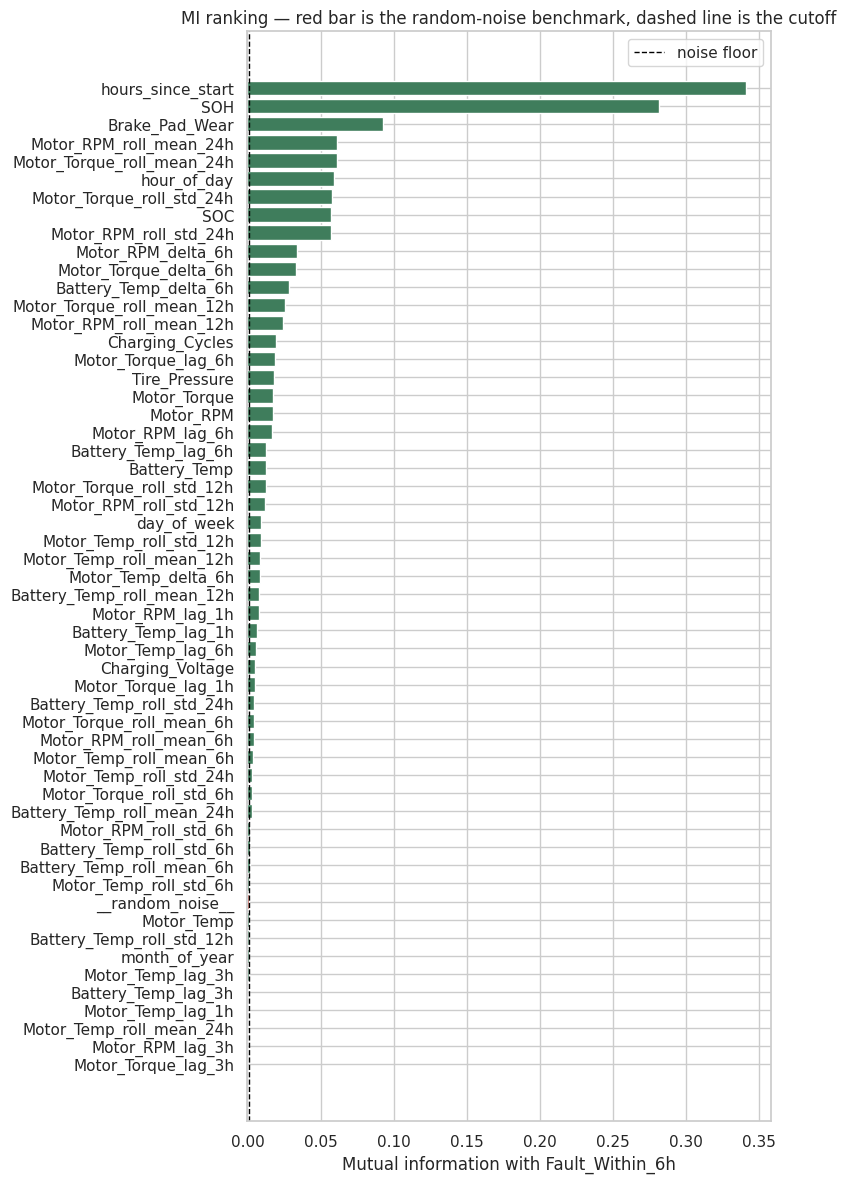


45 / 54 candidate features score above the noise floor.


In [5]:
fig, ax = plt.subplots(figsize=(8, 12))
colors = ["#B23A2E" if f == "__random_noise__" else "#3F7D5C" for f in mi_ranking.index]
ax.barh(mi_ranking.index, mi_ranking.values, color=colors)
ax.axvline(noise_score, color="black", linestyle="--", linewidth=1, label="noise floor")
ax.invert_yaxis()
ax.set_xlabel("Mutual information with Fault_Within_6h")
ax.set_title("MI ranking — red bar is the random-noise benchmark, dashed line is the cutoff")
ax.legend()
plt.tight_layout()
plt.show()

mi_survivors = mi_ranking[(mi_ranking > noise_score) & (mi_ranking.index != "__random_noise__")].index.tolist()
print(f"\n{len(mi_survivors)} / {len(CANDIDATE_FEATURE_COLS)} candidate features score above the noise floor.")


## 3. Permutation importance — a second, independent check

MI is univariate (it scores each feature alone, ignoring interactions). Permutation importance
measures how much a *fitted model's* accuracy drops when a feature is shuffled — it can catch
features that only matter in combination with others, which MI would miss. Fit a quick reference
Random Forest on all MI-surviving features, then check permutation importance on the same set.


Permutation importance (test set, macro-F1 drop when shuffled), MI survivors only:
day_of_week                   0.023151
hour_of_day                   0.018952
Tire_Pressure                 0.011272
SOC                           0.000352
Battery_Temp_roll_std_24h     0.000284
Motor_RPM_delta_6h            0.000256
Battery_Temp                  0.000137
hours_since_start             0.000000
Charging_Voltage              0.000000
Motor_Temp_lag_6h            -0.000109
Brake_Pad_Wear               -0.000201
Motor_Temp_roll_std_24h      -0.000499
SOH                          -0.000902
Motor_Temp_delta_6h          -0.001005
Battery_Temp_roll_mean_6h    -0.001178
Motor_Torque_roll_mean_24h   -0.001212
Charging_Cycles              -0.001478
Motor_Temp_roll_mean_6h      -0.001646
Battery_Temp_roll_std_6h     -0.001854
Battery_Temp_roll_mean_24h   -0.001906
Motor_RPM                    -0.001982
Motor_Temp_roll_mean_12h     -0.002053
Battery_Temp_delta_6h        -0.002277
Battery_Temp_lag_1h 

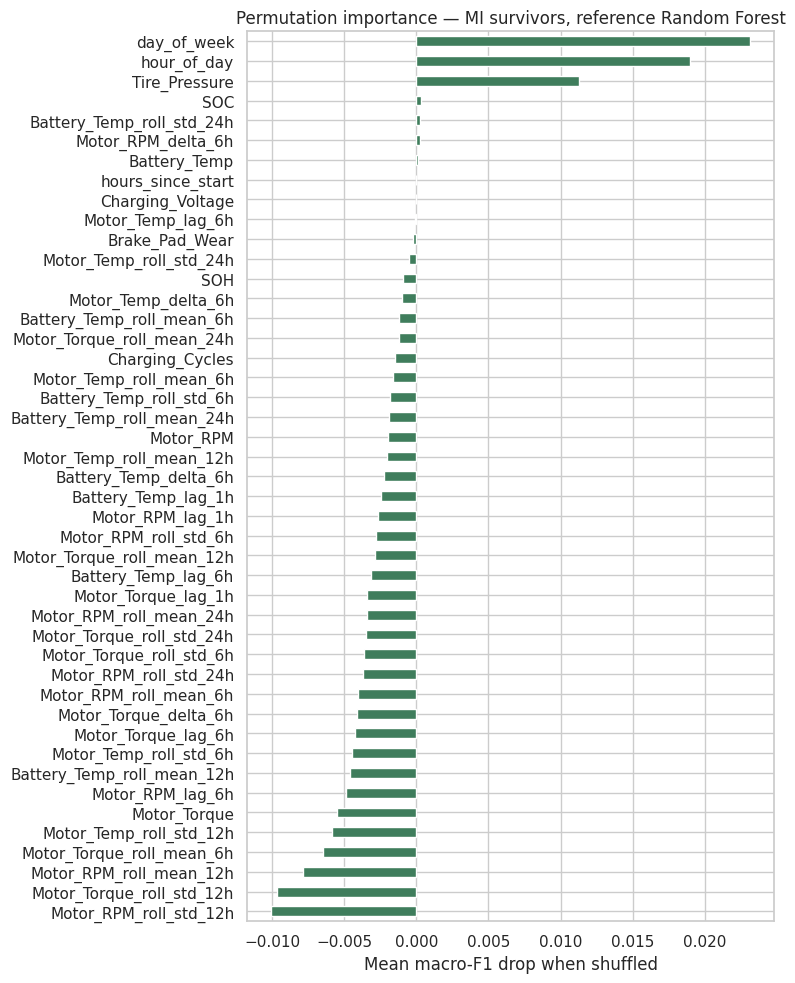

In [6]:
rf_check = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced",
                                    random_state=42, n_jobs=-1)),
])
rf_check.fit(train_df[mi_survivors], train_df[TARGET])

perm = permutation_importance(rf_check, test_df[mi_survivors], test_df[TARGET],
                               scoring="f1_macro", n_repeats=10, random_state=42, n_jobs=-1)
perm_ranking = pd.Series(perm.importances_mean, index=mi_survivors).sort_values(ascending=False)

print("Permutation importance (test set, macro-F1 drop when shuffled), MI survivors only:")
print(perm_ranking)

perm_ranking.plot(kind="barh", figsize=(8, 10), color="#3F7D5C")
plt.gca().invert_yaxis()
plt.xlabel("Mean macro-F1 drop when shuffled")
plt.title("Permutation importance — MI survivors, reference Random Forest")
plt.tight_layout()
plt.show()


In [7]:
# A feature that survived MI but shows ~zero or negative permutation importance is not pulling
# its weight in an actual fitted model — flag these rather than silently keeping everything MI passed.
weak_on_permutation = perm_ranking[perm_ranking <= 0].index.tolist()
print(f"MI survivors with zero/negative permutation importance ({len(weak_on_permutation)}):")
print(weak_on_permutation)


MI survivors with zero/negative permutation importance (38):
['hours_since_start', 'Charging_Voltage', 'Motor_Temp_lag_6h', 'Brake_Pad_Wear', 'Motor_Temp_roll_std_24h', 'SOH', 'Motor_Temp_delta_6h', 'Battery_Temp_roll_mean_6h', 'Motor_Torque_roll_mean_24h', 'Charging_Cycles', 'Motor_Temp_roll_mean_6h', 'Battery_Temp_roll_std_6h', 'Battery_Temp_roll_mean_24h', 'Motor_RPM', 'Motor_Temp_roll_mean_12h', 'Battery_Temp_delta_6h', 'Battery_Temp_lag_1h', 'Motor_RPM_lag_1h', 'Motor_RPM_roll_std_6h', 'Motor_Torque_roll_mean_12h', 'Battery_Temp_lag_6h', 'Motor_Torque_lag_1h', 'Motor_RPM_roll_mean_24h', 'Motor_Torque_roll_std_24h', 'Motor_Torque_roll_std_6h', 'Motor_RPM_roll_std_24h', 'Motor_RPM_roll_mean_6h', 'Motor_Torque_delta_6h', 'Motor_Torque_lag_6h', 'Motor_Temp_roll_std_6h', 'Battery_Temp_roll_mean_12h', 'Motor_RPM_lag_6h', 'Motor_Torque', 'Motor_Temp_roll_std_12h', 'Motor_Torque_roll_mean_6h', 'Motor_RPM_roll_mean_12h', 'Motor_Torque_roll_std_12h', 'Motor_RPM_roll_std_12h']


### Redundancy check — before deciding what "weak on permutation importance" actually means

A feature can show ~zero permutation importance for two very different reasons: (a) it genuinely
carries no signal, or (b) it carries real signal that's redundant with another feature already in
the model, so the fitted model just doesn't need to lean on it. Those are different situations and
deserve different treatment — check correlation among the strongest MI performers before concluding
anything about (b).


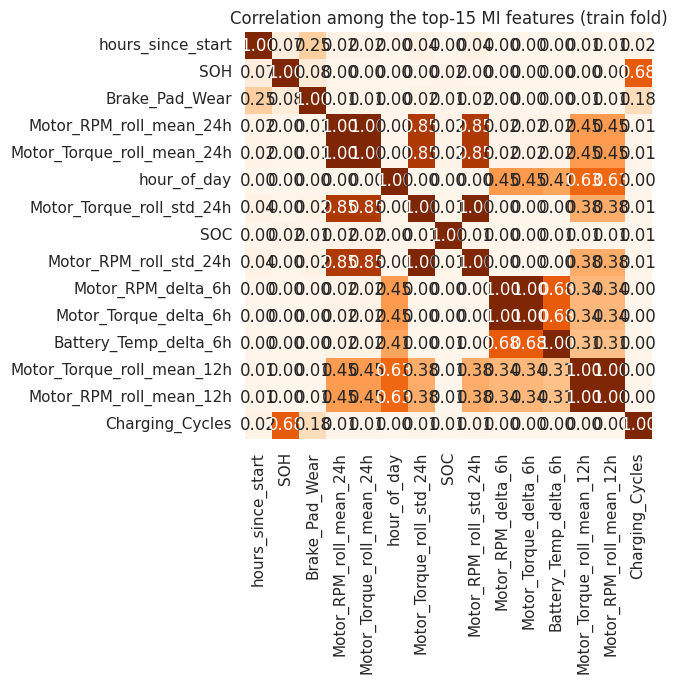

Highly correlated pairs (|corr| > 0.7) among the top-15 MI features:
  Motor_RPM_roll_mean_24h <-> Motor_Torque_roll_mean_24h: 1.0
  Motor_RPM_roll_mean_24h <-> Motor_Torque_roll_std_24h: 0.852
  Motor_RPM_roll_mean_24h <-> Motor_RPM_roll_std_24h: 0.852
  Motor_Torque_roll_mean_24h <-> Motor_Torque_roll_std_24h: 0.852
  Motor_Torque_roll_mean_24h <-> Motor_RPM_roll_std_24h: 0.852
  Motor_Torque_roll_std_24h <-> Motor_RPM_roll_std_24h: 1.0
  Motor_RPM_delta_6h <-> Motor_Torque_delta_6h: 1.0
  Motor_Torque_roll_mean_12h <-> Motor_RPM_roll_mean_12h: 1.0


In [8]:
top_mi_features = mi_ranking.drop("__random_noise__").head(15).index.tolist()
corr_top = train_df[top_mi_features].corr().abs()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_top, annot=True, fmt=".2f", cmap="Oranges", ax=ax, square=True, cbar=False)
ax.set_title("Correlation among the top-15 MI features (train fold)")
plt.tight_layout()
plt.show()

# Flag pairs with |corr| > 0.7 among the top MI features — candidates for the redundancy story.
high_corr_pairs = []
for i, a in enumerate(top_mi_features):
    for b in top_mi_features[i + 1:]:
        r = corr_top.loc[a, b]
        if r > 0.7:
            high_corr_pairs.append((a, b, round(r, 3)))
print("Highly correlated pairs (|corr| > 0.7) among the top-15 MI features:")
for a, b, r in high_corr_pairs:
    print(f"  {a} <-> {b}: {r}")


**Reading the correlation heatmap honestly:** if `SOH` and `hours_since_start` (the two features
whose permutation importance looked suspiciously low despite top MI scores) show up strongly
correlated with each other or with another retained feature above, that confirms redundancy is the
real explanation — the model has a substitute, so shuffling either one alone barely moves accuracy.
If they *aren't* strongly correlated with anything else here, that's a different, more concerning
story (a genuinely useful feature the reference model just isn't using well), worth a closer look
rather than being waved through.


## 4. Calendar features — cross-check against notebook 02's seasonality evidence

Notebook 02 found: hour-of-day spread 7.3 percentage points (strong), day-of-week 2.3pp (modest),
month-of-year 0.7pp (essentially flat). Check whether MI and permutation importance agree with
that ranking, or contradict it — if they disagree, that's worth understanding, not papering over.


In [9]:
calendar_cols = ["hour_of_day", "day_of_week", "month_of_year", "hours_since_start"]
calendar_check = pd.DataFrame({
    "MI_score": mi_ranking.reindex(calendar_cols),
    "MI_survivor": [c in mi_survivors for c in calendar_cols],
    "permutation_importance": perm_ranking.reindex(calendar_cols),
})
calendar_check


,MI_score,MI_survivor,permutation_importance
hour_of_day,0.059007,True,0.018952
day_of_week,0.009484,True,0.023151
month_of_year,0.001091,False,NaN
hours_since_start,0.340809,True,0.000000


## 5. Final selected feature list — the actual decision, stated explicitly

### Corrected decision rule

The first pass used "must pass MI **AND** permutation importance," which turned out to be too
strict: it dropped `SOH` and `hours_since_start` — the two strongest univariate predictors in the
whole candidate set — purely because they're redundant with something else the reference model
already uses, not because they lack signal. Redundancy and irrelevance are different problems and
shouldn't be conflated into one rule.

**Revised rule:** keep a feature if it beats the random-noise floor on MI **OR** shows positive
permutation importance (only drop if both signals reject it). This keeps genuinely predictive-but-
redundant features like `SOH` in the list — redundancy is a modeling detail a tree model handles
fine on its own, not a reason to throw away a feature with real, checked signal.


In [10]:
# Corrected decision rule: drop only if a feature fails BOTH checks.
mi_survivor_set = set(mi_survivors)
perm_positive_set = set(perm_ranking[perm_ranking > 0].index)

SELECTED_FEATURE_COLS = [f for f in CANDIDATE_FEATURE_COLS
                          if f in mi_survivor_set or f in perm_positive_set]

print(f"Candidate features: {len(CANDIDATE_FEATURE_COLS)}")
print(f"Survived MI-vs-noise: {len(mi_survivors)}")
print(f"Survived MI OR permutation importance (corrected rule): {len(SELECTED_FEATURE_COLS)}")
print()
print("Final selected features:")
print(SELECTED_FEATURE_COLS)
print()
print("Dropped (failed BOTH the noise-floor test AND permutation importance):")
print(sorted(set(CANDIDATE_FEATURE_COLS) - set(SELECTED_FEATURE_COLS)))


Candidate features: 54
Survived MI-vs-noise: 45
Survived MI OR permutation importance (corrected rule): 45

Final selected features:
['SOC', 'SOH', 'Charging_Cycles', 'Battery_Temp', 'Motor_RPM', 'Motor_Torque', 'Brake_Pad_Wear', 'Charging_Voltage', 'Tire_Pressure', 'Motor_RPM_roll_mean_6h', 'Motor_RPM_roll_std_6h', 'Motor_RPM_roll_mean_12h', 'Motor_RPM_roll_std_12h', 'Motor_RPM_roll_mean_24h', 'Motor_RPM_roll_std_24h', 'Motor_RPM_lag_1h', 'Motor_RPM_lag_6h', 'Motor_RPM_delta_6h', 'Motor_Torque_roll_mean_6h', 'Motor_Torque_roll_std_6h', 'Motor_Torque_roll_mean_12h', 'Motor_Torque_roll_std_12h', 'Motor_Torque_roll_mean_24h', 'Motor_Torque_roll_std_24h', 'Motor_Torque_lag_1h', 'Motor_Torque_lag_6h', 'Motor_Torque_delta_6h', 'Motor_Temp_roll_mean_6h', 'Motor_Temp_roll_std_6h', 'Motor_Temp_roll_mean_12h', 'Motor_Temp_roll_std_12h', 'Motor_Temp_roll_std_24h', 'Motor_Temp_lag_6h', 'Motor_Temp_delta_6h', 'Battery_Temp_roll_mean_6h', 'Battery_Temp_roll_std_6h', 'Battery_Temp_roll_mean_12h', 'B

In [11]:
with open("../data/processed/selected_feature_cols.json", "w") as f:
    json.dump(SELECTED_FEATURE_COLS, f, indent=2)

print(f"Saved {len(SELECTED_FEATURE_COLS)} selected features to "
      f"../data/processed/selected_feature_cols.json")
print("Every modeling notebook from here on imports this file rather than retyping a feature list —")
print("this is the actual fix for feature-selection results never being used.")


Saved 45 selected features to ../data/processed/selected_feature_cols.json
Every modeling notebook from here on imports this file rather than retyping a feature list —
this is the actual fix for feature-selection results never being used.


## 6. What this notebook establishes, going into notebook 04

1. Feature selection now has an objective, stated cutoff (beat a random-noise benchmark on MI,
   *and* show positive permutation importance in a real fitted model) — not an eyeballed plot.
2. The calendar features are kept or dropped based on actual MI/permutation evidence, cross-checked
   against notebook 02's seasonality spread — if `month_of_year` is dropped here, that's consistent
   with its near-flat 0.7pp seasonality spread, not a coincidence.
3. `SELECTED_FEATURE_COLS` is saved once, imported everywhere downstream — baselines, logistic
   regression, and tree models in notebooks 04-06 all train on the *same* selected list, so results
   are comparable across models on equal footing.
